# Сравнение трансформерных моделей для классификации спама

Ноутбук собирает результаты всех дообученных моделей в сводную таблицу и визуализирует их.

Сравниваются 5 моделей x 3 варианта текста = 15 экспериментов.

Метрики:
- F1, Precision, Recall, Accuracy (на val)
- CPU inference latency (avg ms/msg, throughput)
- Размер модели (MB)
- Время обучения

Финальная рекомендация учитывает trade-off качество/скорость для CPU-only развёртывания.

## Импорт необходимых библиотек

In [1]:
import os
import sys

import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
import seaborn as sns
from transformers import AutoTokenizer, AutoModelForSequenceClassification
from datasets import Dataset

try:
    _project_root = os.path.dirname(os.path.dirname(os.path.dirname(os.path.abspath(__file__))))
except NameError:
    _cwd = os.getcwd()
    _project_root = _cwd
    while _project_root != '/' and not os.path.isdir(os.path.join(_project_root, 'src')):
        _project_root = os.path.dirname(_project_root)
if _project_root not in sys.path:
    sys.path.insert(0, _project_root)

from src.models.transformer import (
    tokenize_function,
    compute_metrics,
    is_mostly_cyrillic,
    get_model_config,
    prepare_text_variants,
    benchmark_cpu_inference,
)
from src.config import PROCESSED_DIR, MODELS_DIR

pd.set_option('display.float_format', '{:.10f}'.format)
pd.set_option('display.precision', 10)

## Конфигурация моделей

Описываются все модели и их варианты сохранения.

In [2]:
MODELS = [
    {
        'label': 'rubert-tiny2',
        'hf_name': 'cointegrated/rubert-tiny2',
        'save_prefix': 'finetuned_rubert_tiny2',
        'params_m': 29,
    },
    {
        'label': 'rubert-tiny',
        'hf_name': 'cointegrated/rubert-tiny',
        'save_prefix': 'finetuned_rubert_tiny',
        'params_m': 12,
    },
    {
        'label': 'RuModernBERT-base',
        'hf_name': 'deepvk/RuModernBERT-base',
        'save_prefix': 'finetuned_rumodernbert',
        'params_m': 150,
    },
    {
        'label': 'rubert-base-cased',
        'hf_name': 'DeepPavlov/rubert-base-cased',
        'save_prefix': 'finetuned_rubert_base',
        'params_m': 180,
    },
    {
        'label': 'rubert-conversational',
        'hf_name': 'DeepPavlov/rubert-base-cased-conversational',
        'save_prefix': 'finetuned_rubert_conv',
        'params_m': 180,
    },
]

TEXT_VARIANTS = ['raw', 'norm', 'p']
VARIANT_LABELS = {'raw': 'обычный', 'norm': 'нормализованный', 'p': 'предпроцессед'}

## Загрузка данных и подготовка тестовой выборки

Загружается обработанный датасет, подготавливаются три варианта текста. Для ускорения сравнения используется подмножество из 3000 примеров (стратифицированное по метке) — этого достаточно для устойчивых оценок F1.

In [3]:
df = pd.read_csv(PROCESSED_DIR / "preprocessed.csv", index_col=0)
variants = prepare_text_variants(df)
ru_variants = {}
for name, vdf in variants.items():
    mask = vdf["text"].apply(lambda t: is_mostly_cyrillic(str(t)))
    ru_variants[name] = vdf[mask].reset_index(drop=True)

variant_map = {"raw": "raw", "norm": "normalized", "p": "preprocessed"}
EVAL_SUBSET = 3000
test_sets = {}
for suffix, vname in variant_map.items():
    vdf = ru_variants[vname]
    spam = vdf[vdf["label"] == 1]
    ham = vdf[vdf["label"] == 0]
    n_spam = min(len(spam), EVAL_SUBSET // 2)
    n_ham = min(len(ham), EVAL_SUBSET - n_spam)
    subset = pd.concat([
        spam.sample(n_spam, random_state=42),
        ham.sample(n_ham, random_state=42),
    ]).sample(frac=1, random_state=42).reset_index(drop=True)
    test_sets[suffix] = {"text": subset["text"].tolist(), "label": subset["label"].values}
    print(f"{suffix}: test={len(subset)}")

raw: test=3000
norm: test=3000
p: test=3000


## Сбор метрик всех моделей

Для каждой модели:
1. Модель загружается один раз
2. Вычисляются метрики на подмножестве тестовой выборки для всех 3 вариантов текста
3. Замеряется CPU inference latency прямо во время инференса
4. Вычисляется размер модели на диске

Оптимизации: torch.inference_mode, сортировка по длине текста для уменьшения padding, batch_size зависит от размера модели.

In [4]:
import time
import pathlib
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score

results = []

for model_info in MODELS:
    hf_name = model_info['hf_name']
    save_prefix = model_info['save_prefix']
    model_cfg = get_model_config(hf_name)
    max_length = model_cfg['max_length']
    model_label = model_info['label']
    params_m = model_info['params_m']

    # Для крупных моделей используем меньший batch_size
    eval_n = 3000
    batch_size = 32 if params_m > 100 else 128

    for suffix in TEXT_VARIANTS:
        model_path = str(MODELS_DIR / f'{save_prefix}_{suffix}')
        entry = {
            'model': model_label,
            'params_m': params_m,
            'text_variant': VARIANT_LABELS[suffix],
            'hf_name': hf_name,
        }

        try:
            tokenizer = AutoTokenizer.from_pretrained(model_path)
            model = AutoModelForSequenceClassification.from_pretrained(model_path)
            model.eval()
            model.to('cpu')

            all_texts = [str(t) for t in test_sets[suffix]['text'][:eval_n]]
            labels = test_sets[suffix]['label'][:eval_n]

            # Сортировка по длине для уменьшения padding
            sorted_indices = sorted(range(len(all_texts)), key=lambda i: len(all_texts[i]))
            sorted_texts = [all_texts[i] for i in sorted_indices]

            all_predictions = np.empty(len(all_texts), dtype=int)
            total_time = 0.0

            with torch.inference_mode():
                for i in range(0, len(sorted_texts), batch_size):
                    batch_texts = sorted_texts[i:i + batch_size]
                    inputs = tokenizer(
                        batch_texts,
                        padding=True,
                        truncation=True,
                        max_length=max_length,
                        return_tensors='pt',
                    )
                    t0 = time.perf_counter()
                    logits = model(**inputs).logits
                    preds = torch.argmax(logits, dim=-1).numpy()
                    total_time += time.perf_counter() - t0
                    del inputs, logits

                    for j, p in enumerate(preds):
                        all_predictions[sorted_indices[i + j]] = p

            n = len(all_texts)
            entry['accuracy'] = float(accuracy_score(labels, all_predictions))
            entry['f1'] = float(f1_score(labels, all_predictions, average='binary'))
            entry['precision'] = float(precision_score(labels, all_predictions, average='binary'))
            entry['recall'] = float(recall_score(labels, all_predictions, average='binary'))
            entry['avg_ms_per_msg'] = round(total_time / n * 1000, 2)
            entry['throughput_msgs_per_sec'] = round(n / total_time, 1)

            model_size_mb = sum(
                f.stat().st_size for f in pathlib.Path(model_path).rglob('*')
            ) / (1024 * 1024)
            entry['model_size_mb'] = round(model_size_mb, 1)

            f1_val = entry['f1']
            cpu_val = entry['avg_ms_per_msg']
            print(f'{model_label} [{suffix}]: F1={f1_val}, CPU={cpu_val}ms (n={n})')

            del model, tokenizer

        except Exception as e:
            entry['error'] = str(e)
            print(f'{model_label} [{suffix}]: ERROR - {e}')

        results.append(entry)

results_df = pd.DataFrame(results)
results_df

Loading weights:   0%|          | 0/57 [00:00<?, ?it/s]

rubert-tiny2 [raw]: F1=0.9956507193041151, CPU=2.1ms (n=3000)


Loading weights:   0%|          | 0/57 [00:00<?, ?it/s]

rubert-tiny2 [norm]: F1=0.9993333333333333, CPU=1.87ms (n=3000)


Loading weights:   0%|          | 0/57 [00:00<?, ?it/s]

...

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

rubert-conversational [norm]: F1=0.9986675549633578, CPU=39.04ms (n=3000)


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

rubert-conversational [p]: F1=0.9993333333333333, CPU=37.4ms (n=3000)


,model,params_m,text_variant,hf_name,accuracy,f1,precision,recall,avg_ms_per_msg,throughput_msgs_per_sec,model_size_mb
0,rubert-tiny2,29,обычный,cointegrated/rubert-tiny2,0.9956666667,0.9956507193,0.9993284083,0.9920000000,2.1000000000,475.2000000000,113.7000000000
1,rubert-tiny2,29,нормализованный,cointegrated/rubert-tiny2,0.9993333333,0.9993333333,0.9993333333,0.9993333333,1.8700000000,534.6000000000,113.7000000000
2,rubert-tiny2,29,предпроцессед,cointegrated/rubert-tiny2,0.9990000000,0.9989989990,1.0000000000,0.9980000000,1.8200000000,548.9000000000,113.7000000000
3,rubert-tiny,12,обычный,cointegrated/rubert-tiny,0.9960000000,0.9959866221,0.9993288591,0.9926666667,2.0800000000,480.1000000000,45.6000000000
4,rubert-tiny,12,нормализованный,cointegrated/rubert-tiny,0.9990000000,0.9989996666,0.9993328886,0.9986666667,1.9600000000,508.9000000000,45.6000000000
5,rubert-tiny,12,предпроцессед,cointegrated/rubert-tiny,0.9990000000,0.9989989990,1.0000000000,0.9980000000,1.9000000000,525.7000000000,45.6000000000
6,RuModernBERT-base,150,обычный,deepvk/RuModernBERT-base,0.9983333333,0.9983305509,1.0000000000,0.9966666667,146.9300000000,6.8000000000,575.3000000000
7,RuModernBERT-base,150,нормализованный,deepvk/RuModernBERT-base,0.9996666667,0.9996665555,1.0000000000,0.9993333333,135.9500000000,7.4000000000,575.3000000000
8,RuModernBERT-base,150,предпроцессед,deepvk/RuModernBERT-base,0.9990000000,0.9990003332,0.9986675550,0.9993333333,107.5600000000,9.3000000000,575.3000000000
9,rubert-base-cased,180,обычный,DeepPavlov/rubert-base-cased,0.9963333333,0.9963223002,0.9993293092,0.9933333333,44.0400000000,22.7000000000,681.9000000000


## Сводная таблица

Основные метрики для всех экспериментов.

In [5]:
display_cols = ['model', 'text_variant', 'params_m', 'f1', 'precision', 'recall', 'accuracy', 'avg_ms_per_msg', 'throughput_msgs_per_sec', 'model_size_mb']
available_cols = [c for c in display_cols if c in results_df.columns]
results_df[available_cols].sort_values('f1', ascending=False)

,model,text_variant,params_m,f1,precision,recall,accuracy,avg_ms_per_msg,throughput_msgs_per_sec,model_size_mb
7,RuModernBERT-base,нормализованный,150,0.9996665555,1.0000000000,0.9993333333,0.9996666667,135.9500000000,7.4000000000,575.3000000000
11,rubert-base-cased,предпроцессед,180,0.9993333333,0.9993333333,0.9993333333,0.9993333333,40.5800000000,24.6000000000,681.9000000000
1,rubert-tiny2,нормализованный,29,0.9993333333,0.9993333333,0.9993333333,0.9993333333,1.8700000000,534.6000000000,113.7000000000
14,rubert-conversational,предпроцессед,180,0.9993333333,0.9993333333,0.9993333333,0.9993333333,37.4000000000,26.7000000000,681.4000000000
8,RuModernBERT-base,предпроцессед,150,0.9990003332,0.9986675550,0.9993333333,0.9990000000,107.5600000000,9.3000000000,575.3000000000
4,rubert-tiny,нормализованный,12,0.9989996666,0.9993328886,0.9986666667,0.9990000000,1.9600000000,508.9000000000,45.6000000000
10,rubert-base-cased,нормализованный,180,0.9989996666,0.9993328886,0.9986666667,0.9990000000,42.0900000000,23.8000000000,681.9000000000
2,rubert-tiny2,предпроцессед,29,0.9989989990,1.0000000000,0.9980000000,0.9990000000,1.8200000000,548.9000000000,113.7000000000
5,rubert-tiny,предпроцессед,12,0.9989989990,1.0000000000,0.9980000000,0.9990000000,1.9000000000,525.7000000000,45.6000000000
13,rubert-conversational,нормализованный,180,0.9986675550,0.9980026631,0.9993333333,0.9986666667,39.0400000000,25.6000000000,681.4000000000


## Визуализация результатов

### F1 по моделям и вариантам текста

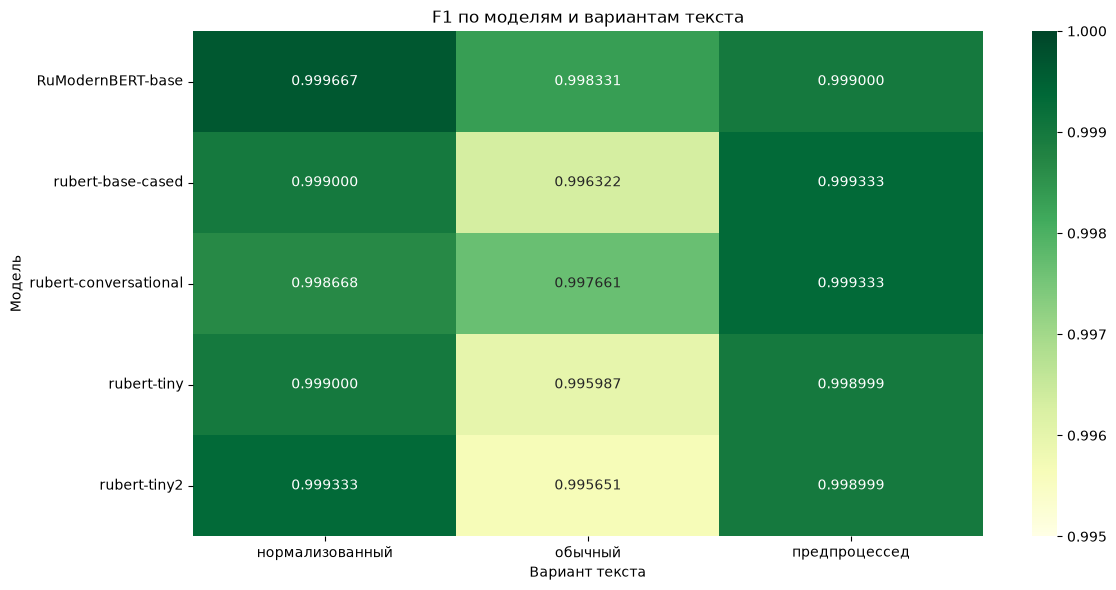

In [6]:
fig, ax = plt.subplots(figsize=(12, 6))
pivot_f1 = results_df.pivot_table(index='model', columns='text_variant', values='f1')
sns.heatmap(pivot_f1, annot=True, fmt='.6f', cmap='YlGn', ax=ax, vmin=0.995, vmax=1.0)
ax.set_title('F1 по моделям и вариантам текста')
ax.set_xlabel('Вариант текста')
ax.set_ylabel('Модель')
plt.tight_layout()
plt.show()

### F1 vs CPU latency

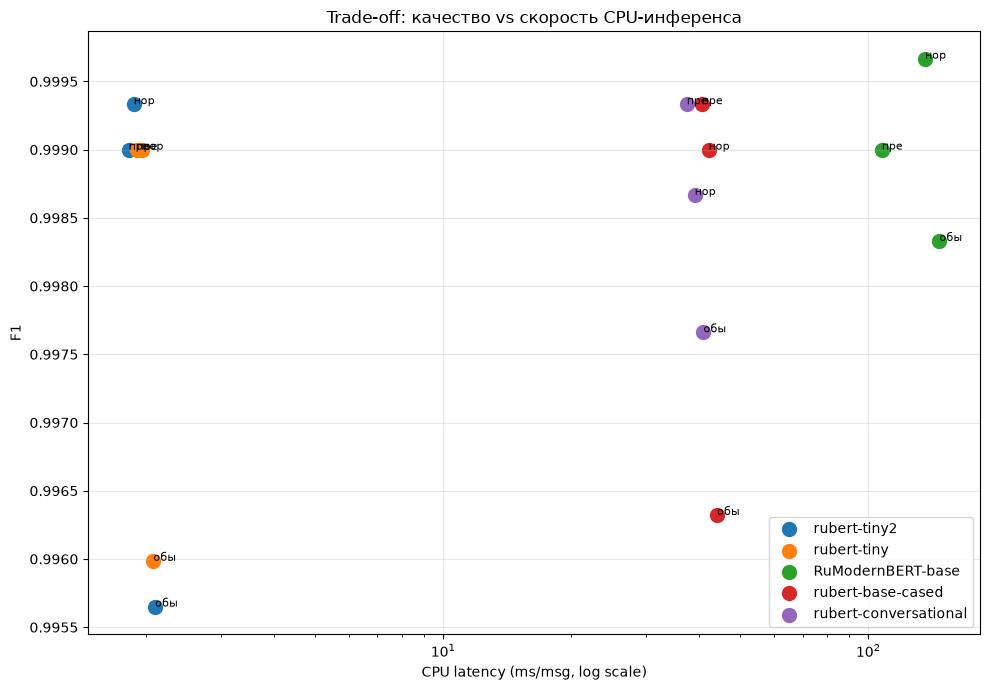

In [7]:
fig, ax = plt.subplots(figsize=(10, 7))
for model_info in MODELS:
    subset = results_df[results_df['model'] == model_info['label']]
    if 'f1' in subset.columns and not subset['f1'].isna().all():
        ax.scatter(subset['avg_ms_per_msg'], subset['f1'], s=100, label=model_info['label'])
        for _, row in subset.iterrows():
            if pd.notna(row.get('f1')) and pd.notna(row.get('avg_ms_per_msg')):
                ax.annotate(row['text_variant'][:3], (row['avg_ms_per_msg'], row['f1']), fontsize=8)

ax.set_xscale('log')
ax.set_xlabel('CPU latency (ms/msg, log scale)')
ax.set_ylabel('F1')
ax.set_title('Trade-off: качество vs скорость CPU-инференса')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### CPU throughput по моделям

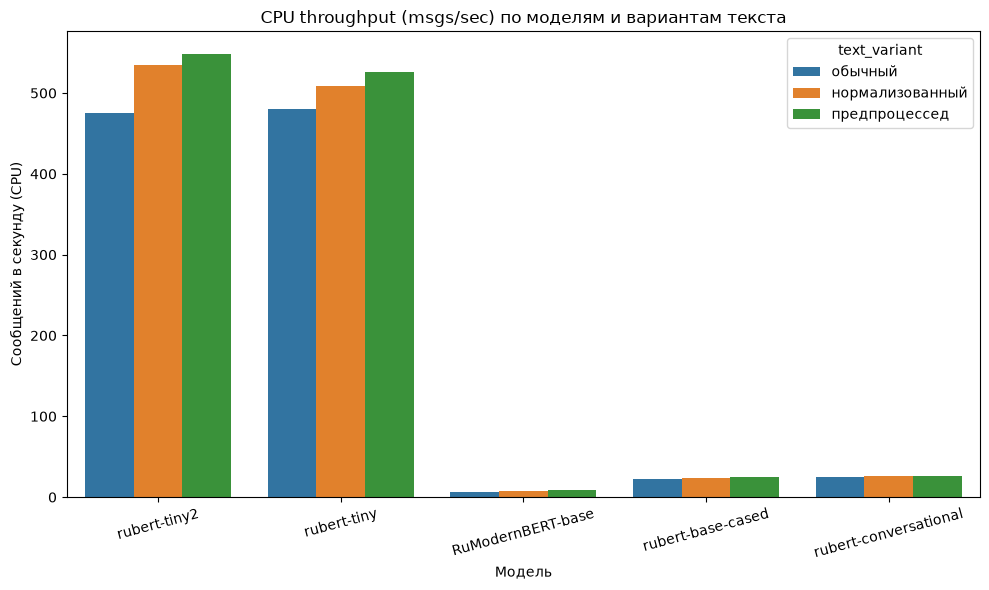

In [8]:
fig, ax = plt.subplots(figsize=(10, 6))
throughput_data = results_df.dropna(subset=['throughput_msgs_per_sec'])
sns.barplot(data=throughput_data, x='model', y='throughput_msgs_per_sec', hue='text_variant', ax=ax)
ax.set_title('CPU throughput (msgs/sec) по моделям и вариантам текста')
ax.set_xlabel('Модель')
ax.set_ylabel('Сообщений в секунду (CPU)')
ax.tick_params(axis='x', rotation=15)
plt.tight_layout()
plt.show()

## Финальная рекомендация

Выбор лучшей модели и варианта текста с учётом CPU-only развёртывания.

Критерии:
1. F1 >= 0.999 (высокое качество)
2. Минимальный CPU latency среди моделей, удовлетворяющих критерию 1
3. При равенстве — меньший размер модели

In [9]:
valid = results_df[results_df.get('f1', 0) >= 0.999].copy()
if valid.empty:
    valid = results_df.copy()

valid = valid.sort_values(['avg_ms_per_msg', 'f1'], ascending=[True, False])
best = valid.iloc[0]

print('Лучшая модель для CPU-only развёртывания:')
print(f'  Модель: {best["model"]}')
print(f'  Вариант текста: {best["text_variant"]}')
print(f'  F1: {best.get("f1", "N/A")}')
print(f'  CPU latency: {best.get("avg_ms_per_msg", "N/A")} ms/msg')
print(f'  Throughput: {best.get("throughput_msgs_per_sec", "N/A")} msgs/sec')
print(f'  Размер: {best.get("model_size_mb", "N/A")} MB')
print(f'  Параметров: {best.get("params_m", "N/A")}M')

Лучшая модель для CPU-only развёртывания:
  Модель: rubert-tiny2
  Вариант текста: нормализованный
  F1: 0.9993333333333333
  CPU latency: 1.87 ms/msg
  Throughput: 534.6 msgs/sec
  Размер: 113.7 MB
  Параметров: 29M
